In [10]:
import pandas as pd

In [15]:
df_efdt = pd.read_csv('./../experiment/modelo_treinado/metricas_por_dia_ExtremelyFastDecisionTreeClassifier.csv')
df_amf = pd.read_csv('./../experiment/modelo_treinado/metricas_por_dia_AMFClassifier.csv')
df_alma = pd.read_csv('./../experiment/modelo_treinado/metricas_por_dia_ALMAClassifier.csv')
df_arf = pd.read_csv('./../experiment/modelo_treinado/metricas_por_dia_ARFClassifier.csv')
df_hat = pd.read_csv('./../experiment/modelo_treinado/metricas_por_dia_HoeffdingAdaptiveTreeClassifier.csv')
df_ht = pd.read_csv('./../experiment/modelo_treinado/metricas_por_dia_HoeffdingTreeClassifier.csv')
df_knn = pd.read_csv('./../experiment/modelo_treinado/metricas_por_dia_KNNClassifier.csv')

In [16]:
columns = ['nome_modelo', 'index_cenario', 'dia_experimento', 'mediaMicro']
df_alg = pd.concat([df_alma, df_amf, df_arf, df_efdt, df_hat, df_ht, df_knn], axis=0)
df_alg = df_alg[df_alg['dia_experimento'] < 15]

In [19]:
df_alg['nome_modelo'] = df_alg['nome_modelo'].apply(lambda x: str(x).replace('Classifier', ''))
df_alg['nome_modelo'] = df_alg['nome_modelo'].apply(lambda x: str(x).replace('HoeffdingTree', 'HT'))
df_alg['nome_modelo'] = df_alg['nome_modelo'].apply(lambda x: str(x).replace('ExtremelyFastDecisionTree', 'EFDT'))
df_alg['nome_modelo'] = df_alg['nome_modelo'].apply(lambda x: str(x).replace('HoeffdingAdaptiveTree', 'HAT'))

In [20]:
df_alg[df_alg['index_cenario'] == 0]['nome_modelo'].unique()

array(['ALMA', 'AMF', 'ARF', 'EFDT', 'HAT', 'HT', 'KNN'], dtype=object)

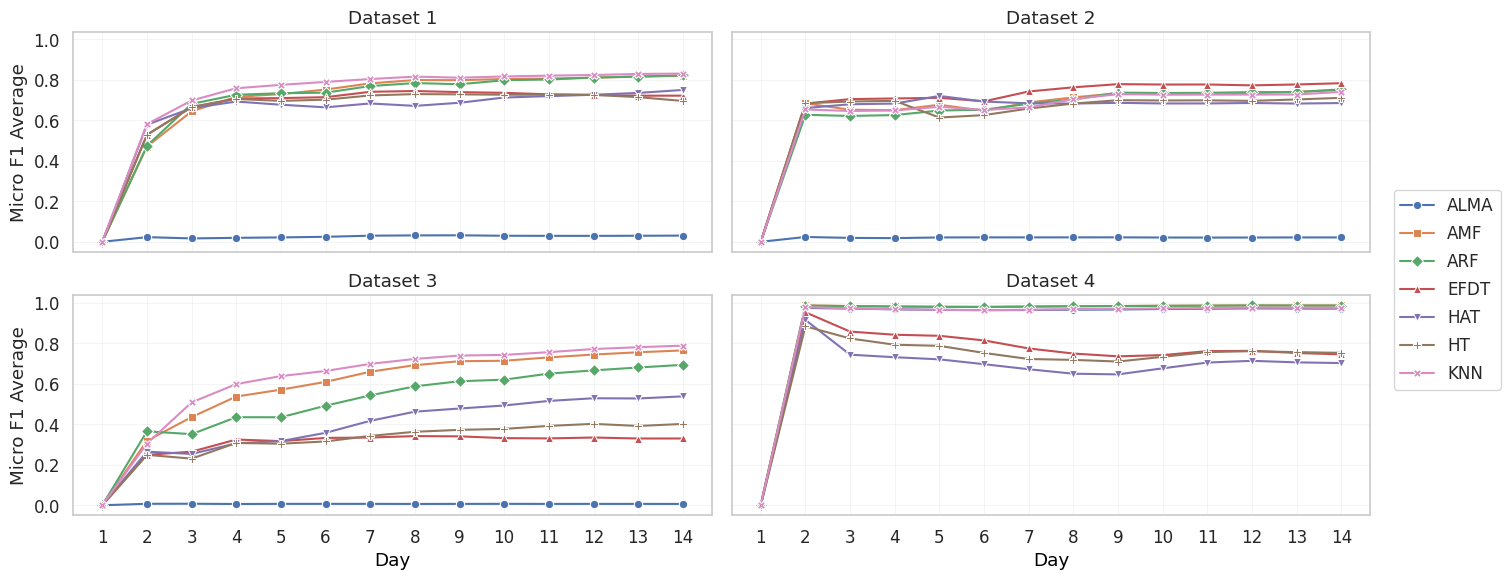

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    font_scale=1.1,
    rc={
        "grid.color": "0.8",
        "grid.linewidth": 0.5,
        "grid.alpha": 0.3
    }
)

mapeamento_cores = {
    "ALMA": 'blue',
    "AMF": 'orange',
    "ARF": 'red',
    "EFDT": 'green',
    "HAT": 'purple',
    "HT": 'brown',
    "KNN": 'gray'
}

cenarios = [0, 1, 2, 3]
hue_order = ["ALMA", "AMF", "ARF", "EFDT", "HAT", "HT", "KNN"]

marker_sim = {
    "ALMA": 'o',
    "AMF": 's',
    "ARF": 'D',
    "EFDT": '^',
    "HAT": 'v',
    "HT": 'P',
    "KNN": 'X'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 6), sharex=True, sharey=True)
axes = axes.ravel()

handles, labels = None, None

for i, c in enumerate(cenarios):
    ax = axes[i]
    data_c = df_alg[df_alg['index_cenario'] == c]

    sns.lineplot(
        data=data_c,
        x="dia_experimento",
        y="mediaMicro",
        hue="nome_modelo",
        hue_order=hue_order,
        # palette=mapeamento_cores,
        style="nome_modelo",       # usa o mesmo semantic para markers
        markers=marker_sim,        # dicionário de marcadores
        dashes=False,              # só muda o marker, linhas sólidas
        ax=ax,
        legend=(i == 0)
    )

    ax.set_title(f"Dataset {c + 1}")
    ax.set_xlabel("Day", color="black")
    ax.set_ylabel("Micro F1 Average")
    ax.set_xticks(range(1, 15))

    if i == 0 and ax.get_legend() is not None:
        handles, labels = ax.get_legend_handles_labels()
        ax.get_legend().remove()

if handles and labels:
    fig.legend(
        handles, labels,
        loc="center left",
        bbox_to_anchor=(1, 0.5),
        frameon=True,
        ncol=1,
        borderaxespad=0.2,
        labelspacing=0.6
    )

plt.tight_layout()
plt.savefig("avg_microf1.pdf", dpi=300, bbox_inches="tight")
plt.show()

